# Titanic Survival Prediction 🚢

## Introduction

The Titanic disaster is one of the most well-known maritime tragedies in history. 
This project analyzes the Titanic passenger dataset to understand the factors that 
influenced survival and to build a machine learning model capable of predicting 
whether a passenger survived.

The dataset contains passenger information such as age, gender, ticket class, 
fare, and family relationships. Through exploratory data analysis (EDA), data 
cleaning, and feature engineering, we aim to uncover patterns in survival outcomes 
and prepare the data for predictive modeling.

### Objectives
- Explore and understand the dataset
- Identify patterns affecting survival
- Handle missing values and prepare features
- Build and evaluate classification models

## Dataset Description

The dataset contains information about passengers aboard the Titanic.

Key features include:
- Survived: Survival status (0 = No, 1 = Yes)
- Pclass: Passenger class (1st, 2nd, 3rd)
- Sex: Gender of passenger
- Age: Passenger age
- SibSp: Number of siblings/spouses aboard
- Parch: Number of parents/children aboard
- Fare: Ticket fare
- Embarked: Port of embarkation

## 2. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

#### The dataset contains 891 rows and 12 columns.

## 3. Dataset Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Observation
The dataset contains 891 passengers with features such as age,
gender, class, and survival outcome.

## 4. Missing Value Analysis

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Missing values are present in Age, Cabin, and Embarked.

### Missing Value Strategy

- Age: Will be filled using median age.
- Cabin: Contains excessive missing values and will likely be dropped.
- Embarked: Only a few values missing; will be filled using mode.

## 5. Exploratory Data Analysis (EDA)

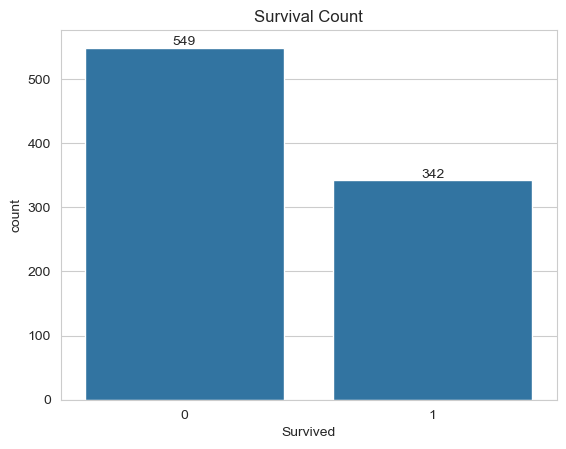

In [7]:
ax = sns.countplot(x="Survived", data=df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Survival Count")
plt.show()

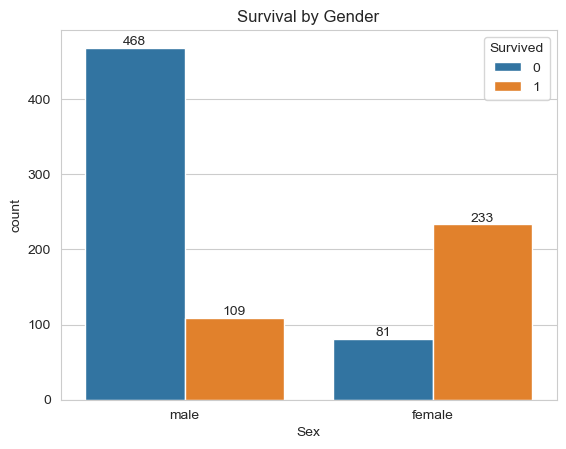

In [8]:
ax = sns.countplot(x="Sex", hue="Survived", data=df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Survival by Gender")
plt.show()

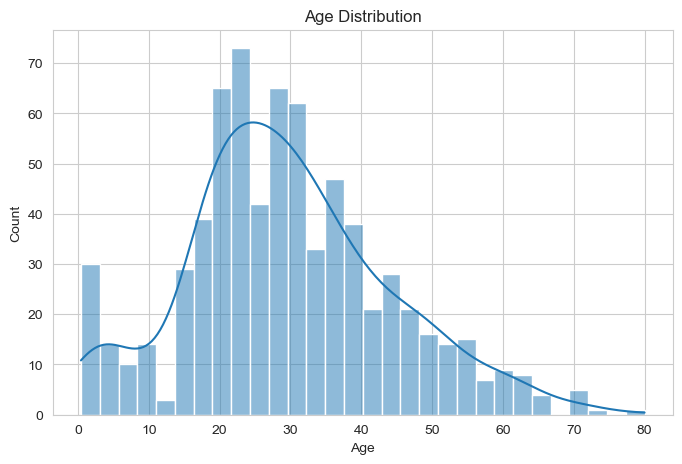

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

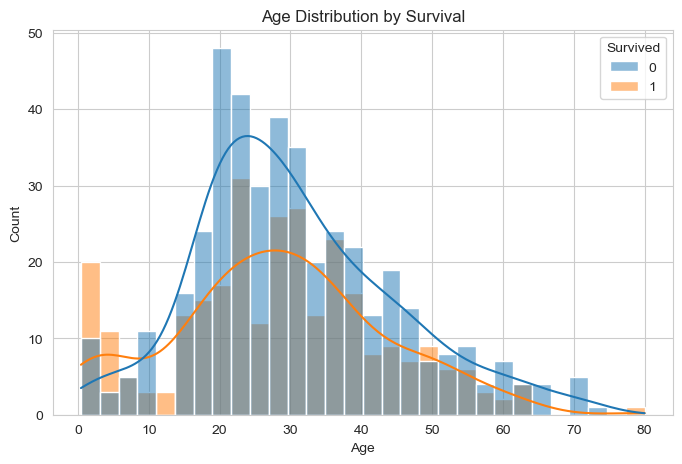

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

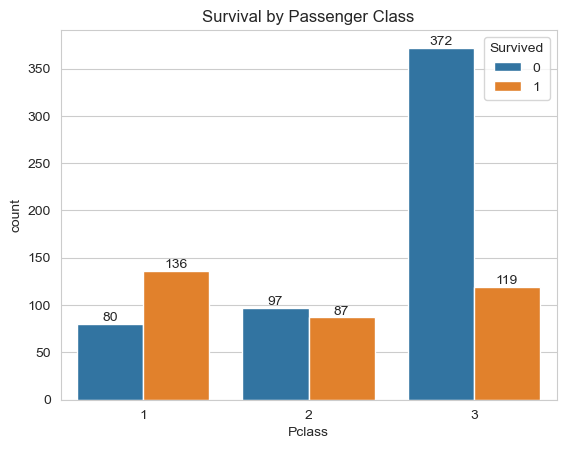

In [11]:
ax = sns.countplot(x="Pclass", hue="Survived", data=df)
for container in ax.containers:
    ax.bar_label(container)

plt.title("Survival by Passenger Class")
plt.show()

In [12]:
survival_rate = round(df['Survived'].mean()*100,2)
print(survival_rate)

38.38


In [13]:
df.groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

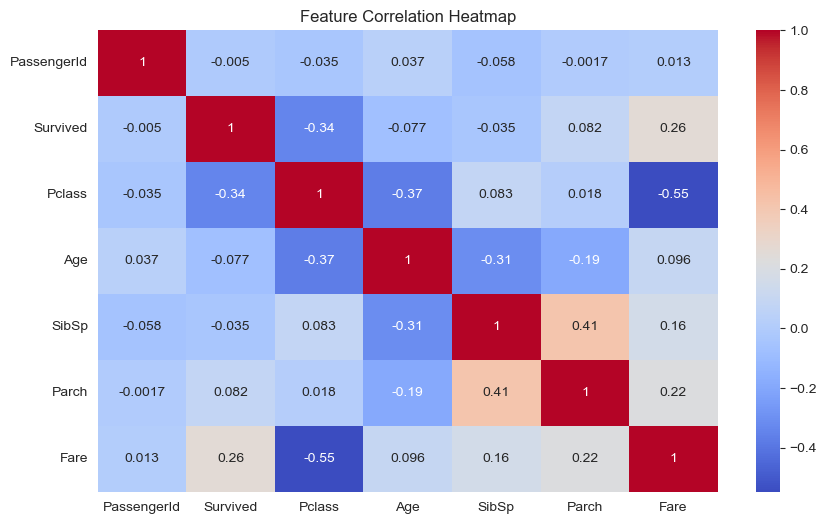

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## 6. Phase 1 Conclusion

- Female passengers had significantly higher survival rates.
- First-class passengers had higher survival probabilities.
- Overall survival rate was approximately 38%.
- Missing values are present in Age, Cabin, and Embarked.

Next step: Data Cleaning & Feature Engineering.